In [1]:
import numpy as np
import cv2
import os
import random
import matplotlib.pyplot as plt
import pickle
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
import tensorflow as tf
from sklearn.metrics import classification_report,confusion_matrix

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
import tensorflow as tf
from tensorflow.keras import layers as L
import keras
from keras.layers import *

## Data Preprocessing

In [6]:
DIRECTORY = r'/kaggle/input/covid-ieee-train-test-split/COVID_IEEE Train Test Split/train'
CATEGORIES = ['covid', 'normal', 'virus']
IMG_SIZE = 224
train_data = []

In [7]:
for category in CATEGORIES:
    folder = os.path.join(DIRECTORY,category)
    #print(folder)
    label = CATEGORIES.index(category)
    for img in os.listdir(folder):
        img_path = os.path.join(folder, img)
        #print(img_path)
        img_arr = cv2.imread(img_path)
        img_arr = cv2.resize(img_arr, (IMG_SIZE, IMG_SIZE))
        #plt.imshow(img_arr)
        #break
        train_data.append([img_arr, label])

In [8]:
len(train_data)

1457

In [9]:
random.shuffle(train_data)

In [10]:
X_train = []
y_train = []

for features, labels in train_data:
    X_train.append(features)
    y_train.append(labels)

In [12]:
DIRECTORY = r'/kaggle/input/covid-ieee-train-test-split/COVID_IEEE Train Test Split/test'
CATEGORIES = ['covid', 'normal', 'virus']
IMG_SIZE = 224
test_data = []

In [13]:
for category in CATEGORIES:
    folder = os.path.join(DIRECTORY,category)
    #print(folder)
    label = CATEGORIES.index(category)
    for img in os.listdir(folder):
        img_path = os.path.join(folder, img)
        #print(img_path)
        img_arr = cv2.imread(img_path)
        img_arr = cv2.resize(img_arr, (IMG_SIZE, IMG_SIZE))
        #plt.imshow(img_arr)
        #break
        test_data.append([img_arr, label])

In [14]:
len(test_data)

366

In [15]:
X_test = []
y_test = []

for features, labels in test_data:
    X_test.append(features)
    y_test.append(labels)

In [16]:
X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)

In [17]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1457, 224, 224, 3), (366, 224, 224, 3), (1457,), (366,))

# Model

In [18]:
data_augmentation = keras.Sequential(
    [
        Normalization(),
        RandomFlip("horizontal"),
        RandomRotation(factor=0.02),
        RandomZoom(
            height_factor=0.2, width_factor=0.2
        ),
        RandomContrast(0.2),
        RandomBrightness(0.2)
    ],
    name="data_augmentation",
)

In [19]:
class SpatialAttentionModule(tf.keras.layers.Layer):
    def __init__(self, kernel_size=3):
        '''
        paper: https://arxiv.org/abs/1807.06521
        code: https://gist.github.com/innat/99888fa8065ecbf3ae2b297e5c10db70
        '''
        super(SpatialAttentionModule, self).__init__()
        self.conv1 = tf.keras.layers.Conv2D(64, kernel_size=kernel_size, 
                                            use_bias=False, 
                                            kernel_initializer='he_normal',
                                            strides=1, padding='same', 
                                            activation=tf.nn.relu)
        self.conv2 = tf.keras.layers.Conv2D(32, kernel_size=kernel_size, 
                                            use_bias=False, 
                                            kernel_initializer='he_normal',
                                            strides=1, padding='same', 
                                            activation=tf.nn.relu)
        self.conv3 = tf.keras.layers.Conv2D(16, kernel_size=kernel_size, 
                                            use_bias=False, 
                                            kernel_initializer='he_normal',
                                            strides=1, padding='same', 
                                            activation=tf.nn.relu)
        self.conv4 = tf.keras.layers.Conv2D(1, kernel_size=kernel_size,  
                                            use_bias=False,
                                            kernel_initializer='he_normal',
                                            strides=1, padding='same', 
                                            activation=tf.math.sigmoid)

    def call(self, inputs):
        avg_out = tf.reduce_mean(inputs, axis=3)
        max_out = tf.reduce_max(inputs,  axis=3)
        x = tf.stack([avg_out, max_out], axis=3) 
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        return self.conv4(x)
    

class ChannelAttentionModule(tf.keras.layers.Layer):
    def __init__(self, ratio=8):
        '''
        paper: https://arxiv.org/abs/1807.06521
        code: https://gist.github.com/innat/99888fa8065ecbf3ae2b297e5c10db70
        '''
        super(ChannelAttentionModule, self).__init__()
        self.ratio = ratio
        self.gapavg = tf.keras.layers.GlobalAveragePooling2D()
        self.gmpmax = tf.keras.layers.GlobalMaxPooling2D()
        
    def build(self, input_shape):
        self.conv1 = tf.keras.layers.Conv2D(input_shape[-1]//self.ratio, 
                                            kernel_size=1, 
                                            strides=1, padding='same',
                                            use_bias=True, activation=tf.nn.relu)
    
        self.conv2 = tf.keras.layers.Conv2D(input_shape[-1], 
                                            kernel_size=1, 
                                            strides=1, padding='same',
                                            use_bias=True, activation=tf.nn.relu)
        super(ChannelAttentionModule, self).build(input_shape)

    def call(self, inputs):
        # compute gap and gmp pooling 
        gapavg = self.gapavg(inputs)
        gmpmax = self.gmpmax(inputs)
        gapavg = tf.keras.layers.Reshape((1, 1, gapavg.shape[1]))(gapavg)   
        gmpmax = tf.keras.layers.Reshape((1, 1, gmpmax.shape[1]))(gmpmax)   
        # forward passing to the respected layers
        gapavg_out = self.conv2(self.conv1(gapavg))
        gmpmax_out = self.conv2(self.conv1(gmpmax))
        return tf.math.sigmoid(gapavg_out + gmpmax_out)
    
    def get_output_shape_for(self, input_shape):
        return self.compute_output_shape(input_shape)

    def compute_output_shape(self, input_shape):
        output_len = input_shape[3]
        return (input_shape[0], output_len)

In [20]:
def cbam(x):
    x_ca = ChannelAttentionModule()(x)
    x = Multiply()([x, x_ca])
    x_sa = SpatialAttentionModule()(x)
    x = Multiply()([x, x_sa])
    return x

In [21]:
def casa_module(x):
    x_ca = ChannelAttentionModule()(x)
    x_ca_out = Multiply()([x_ca, x])
    x_sa = SpatialAttentionModule()(x)
    x_sa_out = Multiply()([x_sa, x])
    # Concatenate
    x_casa = Concatenate()([x_ca_out, x_sa_out])
    return x_casa

In [ ]:
def identity_block(x, f, filters):
    #Retrieve filters
    f1, f2, f3 = filters
    
    x_skip = x
    
    # First Layer
    x = SeparableConv2D(filters=f1, kernel_size=(1,1), strides=(1,1), padding='valid')(x)
    x = BatchNormalization(axis=3)(x)
    x = Activation('relu')(x)
    # Second Layer
    x = SeparableConv2D(filters=f2, kernel_size=(f,f), strides=(1,1), padding='same')(x)
    x = BatchNormalization(axis=3)(x)
    x = Activation('relu')(x)
    # Third Layer
    x = SeparableConv2D(filters=f3, kernel_size=(1,1), strides=(1,1), padding='valid')(x)
    x = BatchNormalization(axis=3)(x)
    
    # Add Skip Connection
    x = Add()([x, x_skip])
    x = Activation('relu')(x)
    
    return x

In [ ]:
def convolutional_block(x, f, filters, s=2):
    #Retrieve filters
    f1, f2, f3 = filters
    
    x_skip = x
    
    # First Layer
    x = SeparableConv2D(filters=f1, kernel_size=(1,1), strides=(1,1), padding='valid')(x)
    x = BatchNormalization(axis=3)(x)
    x = Activation('relu')(x)
    # Second Layer
    x = SeparableConv2D(filters=f2, kernel_size=(f,f), strides=(1,1), padding='same')(x)
    x = BatchNormalization(axis=3)(x)
    x = Activation('relu')(x)
    # Third Layer
    x = SeparableConv2D(filters=f3, kernel_size=(1,1), strides=(1,1), padding='valid')(x)
    x = BatchNormalization(axis=3)(x)
    
    # Add Skip Connection
    x_skip = SeparableConv2D(filters=f3, kernel_size=(1,1), strides=(s,s), padding='valid')(x_skip)
    x_skip = BatchNormalization(axis=3)(x_skip)
    x = Add()([x, x_skip])
    x = Activation('relu')(x)
    
    return x

In [22]:
def inverted_residual_block(inputs, num_filters, strides=1, expansion_ratio=1):
    # point-wise conv
    x = L.Conv2D(filters=expansion_ratio*inputs.shape[-1],
                 kernel_size=1,
                 padding='same',
                 use_bias=False)(inputs)
    x = L.BatchNormalization()(x)
    x = L.Activation('swish')(x)
    
    # depth-wise conv
    x = L.DepthwiseConv2D(kernel_size=3,
                          strides=strides,
                          padding='same',
                          use_bias=False)(x)
    x = L.BatchNormalization()(x)
    x = L.Activation('swish')(x)
    
    # point-wise conv
    x = L.Conv2D(filters=num_filters,
                 kernel_size=1,
                 padding='same',
                 use_bias=False)(x)
    x = L.BatchNormalization()(x)
    
    # Residual Connection
    if strides == 1 and (inputs.shape == x.shape):
        return L.Add()([inputs, x])
    return x
    

In [307]:
inputs = Input((224,224,3))
#x = ZeroPadding2D((3,3))(inputs)

x = SeparableConv2D(64, (3,3), strides=(2,2))(inputs)
x = BatchNormalization(axis=3)(x)
x = Activation('relu')(x)

x = SeparableConv2D(64, (3,3), activation='relu')(x)
x = MaxPooling2D((2,2))(x)
x = inverted_residual_block(x, 64, strides=1, expansion_ratio=2)

x1 = MaxPooling2D((2,2))(x)
x2 = casa_module(x)
x2 = MaxPooling2D((2,2))(x)
x = Concatenate()([x1, x2])


x = SeparableConv2D(128, (3,3), activation='relu')(x)
x = MaxPooling2D((2,2))(x)
x = SeparableConv2D(256, (3,3), activation='relu')(x)
x = MaxPooling2D((2,2))(x)
x = SeparableConv2D(256, (3,3), activation='relu')(x)
x = MaxPooling2D((2,2))(x)

In [308]:
cnn = keras.Model(inputs, x)

In [309]:
cnn.summary()

Model: "model_35"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_82 (InputLayer)          [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 separable_conv2d_150 (Separabl  (None, 111, 111, 64  283        ['input_82[0][0]']               
 eConv2D)                       )                                                                 
                                                                                                  
 batch_normalization_154 (Batch  (None, 111, 111, 64  256        ['separable_conv2d_150[0][0]']   
 Normalization)                 )                                                          

In [315]:
model = tf.keras.Sequential([
    InputLayer((224,224,3)),
    data_augmentation,
    cnn,
    #Flatten(),
    GlobalAveragePooling2D(),
    #BatchNormalization(),
    Dropout(0.75),
    Dense(512, activation='relu'),
    Dropout(0.75),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

In [316]:
model.summary()

Model: "sequential_43"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 data_augmentation (Sequenti  (None, 224, 224, 3)      7         
 al)                                                             
                                                                 
 model_35 (Functional)       (None, 1, 1, 256)         144027    
                                                                 
 global_average_pooling2d_82  (None, 256)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dropout_124 (Dropout)       (None, 256)               0         
                                                                 
 dense_214 (Dense)           (None, 512)               131584    
                                                                 
 dropout_125 (Dropout)       (None, 512)             

In [317]:
# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [318]:
history = model.fit(X_train, y_train, 
                    validation_data=[X_test, y_test],
                    #class_weight=class_weights,
                    epochs=50, batch_size=32)

Epoch 1/50
46/46 [==============================] - 11s 80ms/step - loss: 0.7998 - accuracy: 0.5628 - val_loss: 0.7414 - val_accuracy: 0.7951
Epoch 2/50
46/46 [==============================] - 3s 71ms/step - loss: 0.2850 - accuracy: 0.9149 - val_loss: 0.2708 - val_accuracy: 0.9262
Epoch 3/50
46/46 [==============================] - 3s 74ms/step - loss: 0.2192 - accuracy: 0.9396 - val_loss: 0.1629 - val_accuracy: 0.9617
Epoch 4/50
46/46 [==============================] - 3s 71ms/step - loss: 0.2010 - accuracy: 0.9348 - val_loss: 0.2450 - val_accuracy: 0.9235
Epoch 5/50
46/46 [==============================] - 3s 70ms/step - loss: 0.2104 - accuracy: 0.9355 - val_loss: 0.1450 - val_accuracy: 0.9563
Epoch 6/50
46/46 [==============================] - 3s 70ms/step - loss: 0.1882 - accuracy: 0.9410 - val_loss: 0.2878 - val_accuracy: 0.9071
Epoch 7/50
46/46 [==============================] - 3s 73ms/step - loss: 0.1856 - accuracy: 0.9472 - val_loss: 0.2045 - val_accuracy: 0.9180
Epoch 8/50
4

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


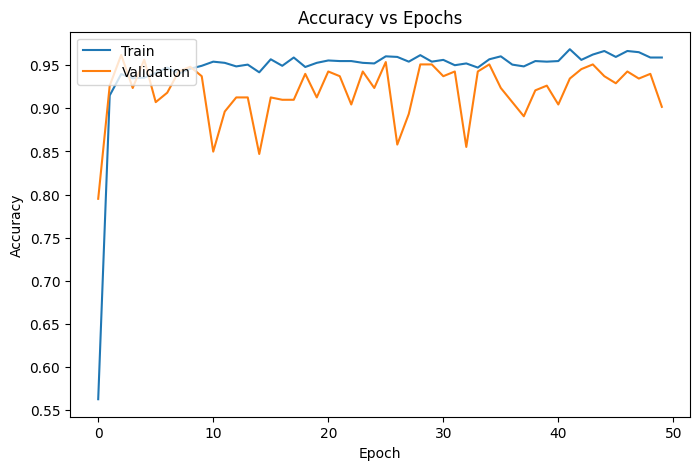

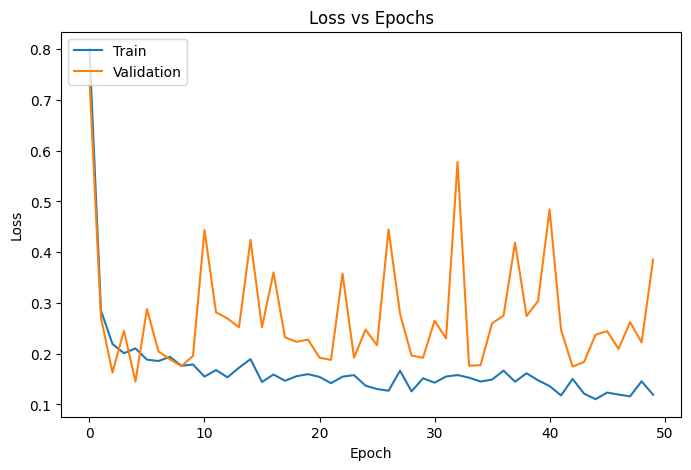

In [319]:
print(history.history.keys())

#  "Accuracy"
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy vs Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig('acc_97_depthwiseCaSa.png', dpi=1200)
plt.show()

# "Loss"
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss vs Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig('loss_97_depthwiseCaSa.png', dpi=1200)
plt.show()

## Performance Evaluation

In [43]:
y_pred = model.predict(X_test)

12/12 [==============================] - 0s 9ms/step


In [ ]:
y_pred = np.argmax(y_pred, axis=1)
y_pred

In [ ]:
y_true = y_test

In [ ]:
print(classification_report(y_true, y_pred))